In [72]:
from Convnets import ConvLayer, Pool
from NeuralNetwork import NeuralNetwork
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from NeuralNetworks.NpAutograd import softmax
from TrainHelpers import get_mnist, train_on_optims, run_test, cosine_annealing_schedule, batcher, get_metrics
import NpAutograd as npa
import VecOptim as vopt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
class LeNet5:
    """Simple helper class so that I can easily create a LeNet5 model. Not fancy or advisable, but it gets the job done."""
    def __init__(self):
        self.conv1 = ConvLayer(kernel_size=5, in_channels=1, out_channels=6, padding=2, stride=1, activation=npa.sigmoid)
        self.pool1 = Pool(kernel_size=2, stride=2, type="avg")
        self.conv2 = ConvLayer(kernel_size=5, in_channels=6, out_channels=16, padding=0, stride=1, activation=npa.sigmoid)
        self.pool2 = Pool(kernel_size=2, stride=2, type="avg")
        self.nn = NeuralNetwork(input_size=16*5*5, output_size=10, hidden=[120, 84], activation=npa.sigmoid)

    def __call__(self, x:npa.Tensor):
        c1 = self.conv1(x)
        p1 = self.pool1(c1)
        c2 = self.conv2(p1)
        p2 = self.pool2(c2)
        return self.nn(p2.reshape((-1, 16*5*5)))
    def get_params(self):
        return self.conv1.get_params() + self.conv2.get_params() + self.nn.get_params()

In [74]:
train_data, train_labels, test_data, test_labels = get_mnist()
train_data = train_data.reshape(-1, 1, 28, 28)
test_data = test_data.reshape(-1, 1, 28, 28)

In [75]:
model = LeNet5()

In [76]:
num_epochs = 20
batch_size = 512
schedule = cosine_annealing_schedule(num_epochs, batch_size, len(train_data), warmup_steps=0.1)
optim = vopt.Adam(model.get_params(), lr=1e-1, momentum=0.99, beta2=0.9, lr_func=None, reg_type="L2", reg_param=1e-6,)

Epoch 0 loss: 13.23887552709983
Epoch 1 loss: 10.413842481560605
Epoch 2 loss: 10.170916204370597
Epoch 3 loss: 9.754201240721484
Epoch 4 loss: 7.545524247204139
Epoch 5 loss: 7.441088998499256
Epoch 6 loss: 7.324036964238076
Epoch 7 loss: 7.808073180463743
Epoch 8 loss: 8.408223589052119
Epoch 9 loss: 6.22107942931277
Epoch 10 loss: 6.532517418797105
Epoch 11 loss: 6.60054276569268
Epoch 12 loss: 6.942908525937601
Epoch 13 loss: 6.983677529111656
Epoch 14 loss: 7.283644032900675
Epoch 15 loss: 6.639091501177524
Epoch 16 loss: 7.349499005200222
Epoch 17 loss: 7.23158606740316
Epoch 18 loss: 7.54112801988516
Epoch 19 loss: 6.099018069000305


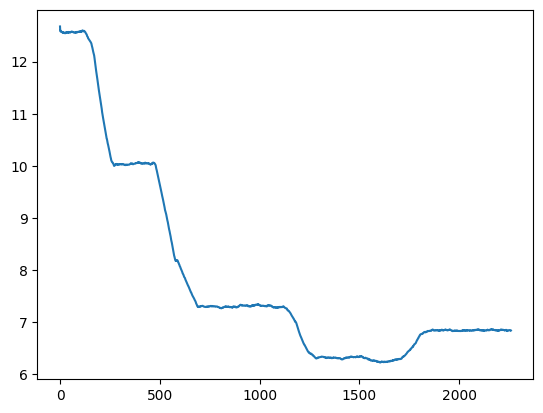

In [77]:
#Testing if the model actually runs. I'm guessing the for loop makes it really slow?
#It does seem to run and kind of learn, however it does not seem to be as good as regular NN as it oscillates around local minima (or there is a bug)
loss_vals = []
total_steps = 0
for i in range(num_epochs):
    for batch in batcher(train_data, train_labels, batch_size):
        x, y = batch
        logits = model(x)
        loss = npa.logloss(logits, y)
        loss.backward()
        optim.step()
        loss_vals.append(loss.v)
        total_steps += 1
    print(f"Epoch {i} loss: {loss.v}")
smooth_param = 1 if total_steps < 100 else 10 if total_steps < 1000 else 100
loss_vals = np.array(loss_vals)
smoothed_losses = (loss_vals.cumsum()[smooth_param:] - loss_vals.cumsum()[:-smooth_param])/smooth_param
plt.plot(smoothed_losses)

In [78]:
logits = model(test_data[:1])
loss = npa.logloss(logits, train_labels[:2]).mean()
loss.backward()
for p in model.get_params():
    print(np.linalg.norm(p.grad))
    p.zero_grad()
# should all be > 1e-8

1.1386624634393365e-14
2.959724911753395e-14
8.417956389103049e-13
9.485865305912258e-14
1.9045637022584853e-10
1.555067592782482e-11
2.025214583200644e-08
2.8090774340226363e-09


In [79]:
probs = npa.softmax(model(test_data)).v
get_metrics(probs, test_labels)

/Users/josecruz/Desktop/Summer 25/ML/Coding_The_ML_Basics/NeuralNetworks/TrainHelpers.py:21: RuntimeWarning: invalid value encountered in divide
  return TP / (TP + FP)


{'confusion_matrix': array([[   0,    0,    0,    0,    0,    0,  980,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0, 1135,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0, 1032,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0, 1010,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0,  982,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0,  892,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0,  958,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0, 1028,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0,  974,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0, 1009,    0,    0,    0]]),
 'per_class': {'accuracy': array([0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.0958, 0.    ,
         0.    , 0.    ]),
  'precision': array([   nan,    nan,    nan,    nan,    nan,    nan, 0.0958,    nan,
            nan,    nan]),
  'recall': array([0., 0., 0., 0., 0., 0

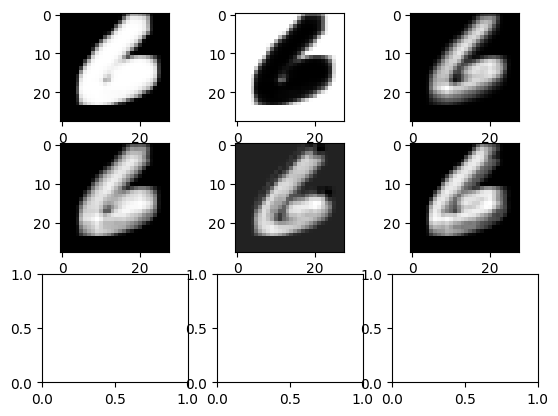

In [80]:
l1 = model.conv1(train_data[-2:-1])
l2 = model.conv2(model.pool1(l1))
l3 = model.pool2(l2)
layers = l1
num_axs = int(np.ceil(np.sqrt(len(layers.v[0]))))
fig, axs = plt.subplots(nrows=num_axs, ncols=num_axs)
axs = axs.flatten()
for i, layer in enumerate(layers.v[0]):
    axs[i].imshow(layer, cmap="gray")

In [81]:
logits = model.nn(l3.reshape((-1, 16*5*5))).v
logits

array([[ 5.27998847,  8.77589093,  2.77232777,  9.47126902,  9.69404801,
        -2.2337689 ,  9.94121516,  1.26866798, -2.31790034,  9.18295139]])